149/149 ━━━━━━━━━━━━━━━━━━━━ 62s 410ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 429ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 411ms/step
Test Accuracy: 100.00%
Test Performance:
                 precision    recall  f1-score   support

Bacterialblight       1.00      1.00      1.00       159
          Blast       1.00      1.00      1.00       144
      Brownspot       1.00      1.00      1.00       160
         Tungro       1.00      1.00      1.00       132

       accuracy                           1.00       595
      macro avg       1.00      1.00      1.00       595
   weighted avg       1.00      1.00      1.00       595



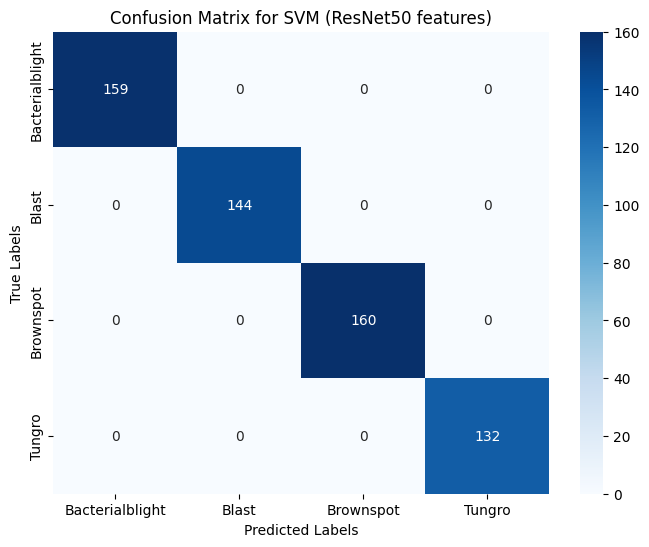

Model saved to svm_resnet50_model_128128.pkl


In [1]:
import os
import numpy as np
import cv2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the ResNet50 model without the top layer (used for feature extraction)
resnet_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Function to load images from directory and assign labels
def load_images_from_directory(directory, target_size=(128, 128)):
    images = []
    labels = []
    class_names = sorted(os.listdir(directory))  
    class_mapping = {name: idx for idx, name in enumerate(class_names)}

    for class_name in class_names:
        class_dir = os.path.join(directory, class_name)
        if not os.path.isdir(class_dir):
            continue
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, target_size)  
            images.append(img)
            labels.append(class_mapping[class_name])

    return np.array(images), np.array(labels), class_mapping

# Function to extract features using a pretrained model
def extract_features(images, model, preprocess_func):
    resized_images = []
    for img in images:
        resized_img = cv2.resize(img, (128, 128))  
        resized_images.append(resized_img)
    resized_images = np.array(resized_images)
    preprocessed_images = preprocess_func(resized_images)  
    features = model.predict(preprocessed_images)
    return features.reshape(features.shape[0], -1)  # Flatten the features

# Load data
train_images, train_labels, class_mapping = load_images_from_directory(r'C:\Users\User\Desktop\MSERMSE_Temperature\New_folder\NEWWORK\train')
val_images, val_labels, _ = load_images_from_directory(r'C:\Users\User\Desktop\MSERMSE_Temperature\New_folder\NEWWORK\val')
test_images, test_labels, _ = load_images_from_directory(r'C:\Users\User\Desktop\MSERMSE_Temperature\New_folder\NEWWORK\test')

# Extract features using ResNet50
x_train_features = extract_features(train_images, resnet_model, preprocess_input)
x_val_features = extract_features(val_images, resnet_model, preprocess_input)
x_test_features = extract_features(test_images, resnet_model, preprocess_input)

# Combine training and validation features
x_train_combined = np.concatenate((x_train_features, x_val_features), axis=0)
y_train_combined = np.concatenate((train_labels, val_labels), axis=0)

# Define the model for classification (SVM)
svm_model = SVC()

# Train the SVM model
svm_model.fit(x_train_combined, y_train_combined)

# Make predictions
test_predictions = svm_model.predict(x_test_features)

# Evaluate the performance
test_accuracy = accuracy_score(test_labels, test_predictions)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print("Test Performance:")
print(classification_report(test_labels, test_predictions, target_names=list(class_mapping.keys())))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=list(class_mapping.keys()), yticklabels=list(class_mapping.keys()))
plt.title(f"Confusion Matrix for SVM (ResNet50 features)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

import joblib  # Add this import for saving and loading the model

# Save the SVM model to a file
model_filename = "svm_resnet50_model_128128.pkl"
joblib.dump(svm_model, model_filename)
print(f"Model saved to {model_filename}")



149/149 ━━━━━━━━━━━━━━━━━━━━ 22s 131ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step
Test Accuracy: 100.00%
Test Performance:
                 precision    recall  f1-score   support

Bacterialblight       1.00      1.00      1.00       159
          Blast       1.00      1.00      1.00       144
      Brownspot       1.00      1.00      1.00       160
         Tungro       1.00      1.00      1.00       132

       accuracy                           1.00       595
      macro avg       1.00      1.00      1.00       595
   weighted avg       1.00      1.00      1.00       595



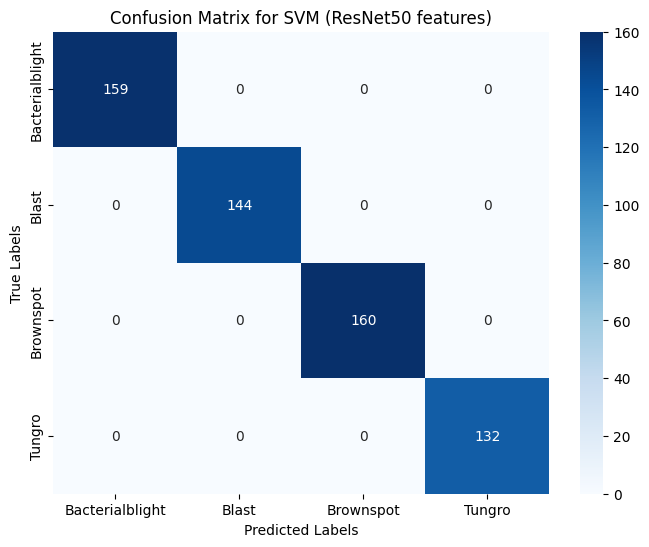

Model saved to svm_resnet50_model_6464.pkl


In [2]:
import os
import numpy as np
import cv2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the ResNet50 model without the top layer (used for feature extraction)
resnet_model = ResNet50(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Function to load images from directory and assign labels
def load_images_from_directory(directory, target_size=(64, 64)):
    images = []
    labels = []
    class_names = sorted(os.listdir(directory))  
    class_mapping = {name: idx for idx, name in enumerate(class_names)}

    for class_name in class_names:
        class_dir = os.path.join(directory, class_name)
        if not os.path.isdir(class_dir):
            continue
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, target_size)  
            images.append(img)
            labels.append(class_mapping[class_name])

    return np.array(images), np.array(labels), class_mapping

# Function to extract features using a pretrained model
def extract_features(images, model, preprocess_func):
    resized_images = []
    for img in images:
        resized_img = cv2.resize(img, (64, 64))  
        resized_images.append(resized_img)
    resized_images = np.array(resized_images)
    preprocessed_images = preprocess_func(resized_images)  
    features = model.predict(preprocessed_images)
    return features.reshape(features.shape[0], -1)  # Flatten the features

# Load data
train_images, train_labels, class_mapping = load_images_from_directory(r'C:\Users\User\Desktop\MSERMSE_Temperature\New_folder\NEWWORK\train')
val_images, val_labels, _ = load_images_from_directory(r'C:\Users\User\Desktop\MSERMSE_Temperature\New_folder\NEWWORK\val')
test_images, test_labels, _ = load_images_from_directory(r'C:\Users\User\Desktop\MSERMSE_Temperature\New_folder\NEWWORK\test')

# Extract features using ResNet50
x_train_features = extract_features(train_images, resnet_model, preprocess_input)
x_val_features = extract_features(val_images, resnet_model, preprocess_input)
x_test_features = extract_features(test_images, resnet_model, preprocess_input)

# Combine training and validation features
x_train_combined = np.concatenate((x_train_features, x_val_features), axis=0)
y_train_combined = np.concatenate((train_labels, val_labels), axis=0)


# Define the model for classification (SVM)
svm_model = SVC()

# Train the SVM model
svm_model.fit(x_train_combined, y_train_combined)

# Make predictions
test_predictions = svm_model.predict(x_test_features)

# Evaluate the performance
test_accuracy = accuracy_score(test_labels, test_predictions)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print("Test Performance:")
print(classification_report(test_labels, test_predictions, target_names=list(class_mapping.keys())))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=list(class_mapping.keys()), yticklabels=list(class_mapping.keys()))
plt.title(f"Confusion Matrix for SVM (ResNet50 features)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

import joblib  # Add this import for saving and loading the model

# Save the SVM model to a file
model_filename = "svm_resnet50_model_6464.pkl"
joblib.dump(svm_model, model_filename)
print(f"Model saved to {model_filename}")

